TABLE 1 Debate Arguments

In [34]:
Debate_Arguments <- data.frame(
  ID = c("A001", "A002", "A003", "A004", "A005", "A006"),
  Position = c("For", "For", "For", "Against", "Against", "Against"),
  Topic = c("Learning", "Productivity", "AI Literacy", "Academic Integrity", "Dependency", "Assessment"),
  Claim = c(
    "AI can provide students with immediate learning support.",
    "AI can help students complete routine academic tasks more efficiently.",
    "Allowing AI use can help students develop AI literacy.",
    "Undisclosed AI-generated work may create academic integrity concerns.",
    "Excessive AI use may reduce students' independent problem-solving practice.",
    "AI use may make it more difficult to determine whether submitted work reflects student learning."
  )
)

Debate_Arguments

ID,Position,Topic,Claim
<chr>,<chr>,<chr>,<chr>
A001,For,Learning,AI can provide students with immediate learning support.
A002,For,Productivity,AI can help students complete routine academic tasks more efficiently.
A003,For,AI Literacy,Allowing AI use can help students develop AI literacy.
A004,Against,Academic Integrity,Undisclosed AI-generated work may create academic integrity concerns.
A005,Against,Dependency,Excessive AI use may reduce students' independent problem-solving practice.
A006,Against,Assessment,AI use may make it more difficult to determine whether submitted work reflects student learning.


In [3]:
For_Arguments <- data.frame(
  ID = c("A001", "A002", "A003"),
  Position = c("For", "For", "For"),
  Topic = c("Learning", "Productivity", "AI Literacy"),
  Claim = c(
    "AI can provide students with immediate learning support.",
    "AI can help students complete routine academic tasks more efficiently.",
    "Allowing AI use can help students develop AI literacy."
  )
)

For_Arguments

ID,Position,Topic,Claim
<chr>,<chr>,<chr>,<chr>
A001,For,Learning,AI can provide students with immediate learning support.
A002,For,Productivity,AI can help students complete routine academic tasks more efficiently.
A003,For,AI Literacy,Allowing AI use can help students develop AI literacy.


TABLE 2 Evidence

In [39]:
Evidence <- data.frame(
  ID = c("A001", "A002", "A003", "A004", "A005", "A006"),
  Evidence_ID = c("E001", "E002", "E003", "E004", "E005", "E006"),
  Evidence_Type = c("Research", "Research", "Policy", "Policy", "Research", "Research"),
  Strength = c("Strong", "Moderate", "Strong", "Strong", "Moderate", "Strong")
)

Evidence

ID,Evidence_ID,Evidence_Type,Strength
<chr>,<chr>,<chr>,<chr>
A001,E001,Research,Strong
A002,E002,Research,Moderate
A003,E003,Policy,Strong
A004,E004,Policy,Strong
A005,E005,Research,Moderate
A006,E006,Research,Strong


In [6]:
table(Debate_Arguments$Position)


Against     For 
      3       3 

In [7]:
nrow(Debate_Arguments)

[1] 6

In [8]:
table(Evidence$Strength)


Moderate   Strong 
       2        4 

In [9]:
nrow(Evidence)

[1] 6

Connect Table Arguments and evidence

In [51]:
knowledge_base <- merge(
  Debate_Arguments,
  Evidence,
  by = "ID"
)

print(knowledge_base)

     ID Position              Topic
1  A001      For           Learning
2  A002      For       Productivity
3  A003      For        AI Literacy
4  A004  Against Academic Integrity
5  A005  Against         Dependency
6  A006  Against         Assessment
7  A007      For         Creativity
8  A007      For         Creativity
9  A008  Against            Privacy
10 A008  Against            Privacy
11 A009      For      Accessibility
12 A009      For      Accessibility
                                                                                              Claim
1                                          AI can provide students with immediate learning support.
2                            AI can help students complete routine academic tasks more efficiently.
3                                            Allowing AI use can help students develop AI literacy.
4                             Undisclosed AI-generated work may create academic integrity concerns.
5                       Excessiv

Convert Evidence

In [41]:
get_score <- function(strength){
  if(strength == "Strong"){
    return(3)
  } else if(strength == "Moderate"){
    return(2)
  } else if(strength == "Weak"){
    return(1)
  } else {
    return(0)
  }
}

get_score("Strong")
get_score("Moderate")
get_score("Weak")

[1] 3

[1] 2

[1] 1

5. Add evidence Score

In [42]:
knowledge_base$Evidence_Score <- sapply(
  knowledge_base$Strength,
  get_score
)

print(knowledge_base)

    ID Position              Topic
1 A001      For           Learning
2 A002      For       Productivity
3 A003      For        AI Literacy
4 A004  Against Academic Integrity
5 A005  Against         Dependency
6 A006  Against         Assessment
                                                                                             Claim
1                                         AI can provide students with immediate learning support.
2                           AI can help students complete routine academic tasks more efficiently.
3                                           Allowing AI use can help students develop AI literacy.
4                            Undisclosed AI-generated work may create academic integrity concerns.
5                      Excessive AI use may reduce students' independent problem-solving practice.
6 AI use may make it more difficult to determine whether submitted work reflects student learning.
  Evidence_ID Evidence_Type Strength Evidence_Score
1        E

6.Evidence Score to Support

In [43]:
classify_support <- function(Evidence_Score){
  if(Evidence_Score == 3){
    return("Strongly Supported")
  } else if(Evidence_Score == 2){
    return("Moderately Supported")
  } else if(Evidence_Score == 1){
    return("Weakly Supported")
  } else {
    return("No Support")
  }
}

classify_support(2)

[1] "Moderately Supported"

7. Add evidence support

In [27]:
knowledge_base$Support_Level <- sapply(
  knowledge_base$Evidence_Score,
  classify_support
)

print(knowledge_base)

    ID Position              Topic
1 A001      For           Learning
2 A002      For       Productivity
3 A003      For        AI Literacy
4 A004  Against Academic Integrity
5 A005  Against         Dependency
6 A006  Against         Assessment
                                                                                             Claim
1                                         AI can provide students with immediate learning support.
2                           AI can help students complete routine academic tasks more efficiently.
3                                           Allowing AI use can help students develop AI literacy.
4                            Undisclosed AI-generated work may create academic integrity concerns.
5                      Excessive AI use may reduce students' independent problem-solving practice.
6 AI use may make it more difficult to determine whether submitted work reflects student learning.
  Evidence_ID Evidence_Type Strength Evidence_Score        Sup

8.Search by Topic

In [29]:
search_topic <- function(topic){
  result <- subset(
    knowledge_base,
    Topic == topic
  )
  if(nrow(result) == 0){
    cat("Topic not found")
  }else{
    print(result)
  }
}

In [30]:
search_topic("Learning")

    ID Position    Topic
1 A001      For Learning
                                                     Claim Evidence_ID
1 AI can provide students with immediate learning support.        E001
  Evidence_Type Strength Evidence_Score      Support_Level
1      Research   Strong              3 Strongly Supported


         FINAL DEBATE REPORT

TOTAL ARGUMENTS: 12 
TOTAL EVIDENCE RECORDS: 9 

--- ARGUMENTS FOR ---
     ID         Topic
1  A001      Learning
2  A002  Productivity
3  A003   AI Literacy
7  A007    Creativity
8  A007    Creativity
11 A009 Accessibility
12 A009 Accessibility
                                                                        Claim
1                    AI can provide students with immediate learning support.
2      AI can help students complete routine academic tasks more efficiently.
3                      Allowing AI use can help students develop AI literacy.
7             AI tools can help students explore creative ideas more broadly.
8             AI tools can help students explore creative ideas more broadly.
11 AI can make quality education more accessible to students in remote areas.
12 AI can make quality education more accessible to students in remote areas.
          Support_Level
1    Strongly Supported
2  Moderately Supported
3    Strongly Supported
7  

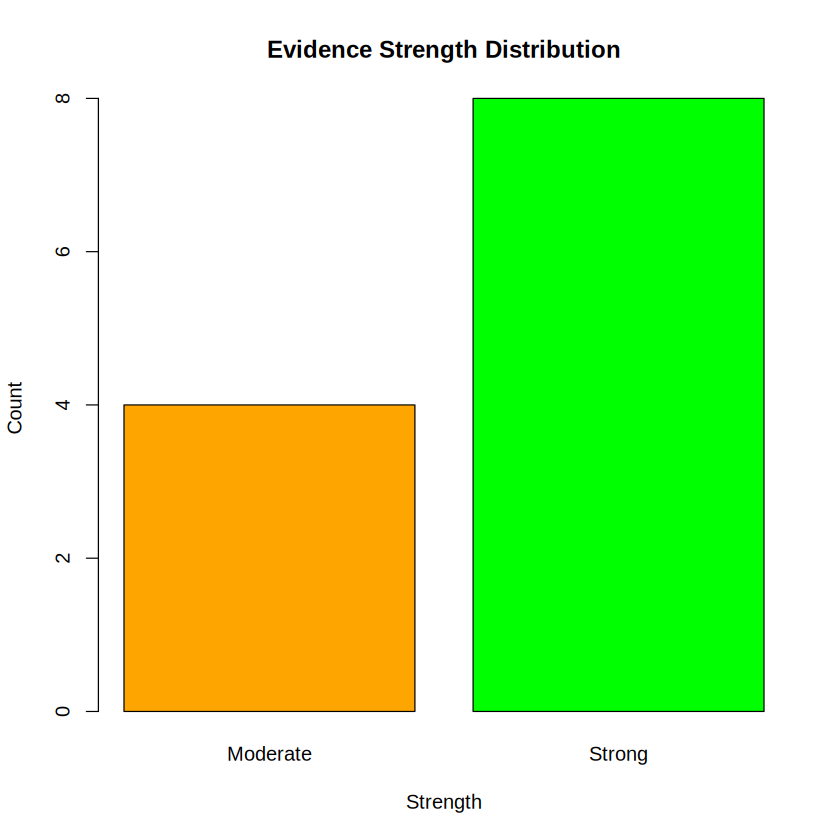

In [46]:
# Add more arguments to existing ones
Debate_Arguments <- rbind(Debate_Arguments, data.frame(
  ID = c("A007", "A008", "A009"),
  Position = c("For", "Against", "For"),
  Topic = c("Creativity", "Privacy", "Accessibility"),
  Claim = c(
    "AI tools can help students explore creative ideas more broadly.",
    "AI systems may collect and misuse student data without consent.",
    "AI can make quality education more accessible to students in remote areas."
  )
))

# Add more evidence to existing ones
Evidence <- rbind(Evidence, data.frame(
  ID = c("A007", "A008", "A009"),
  Evidence_ID = c("E007", "E008", "E009"),
  Evidence_Type = c("Research", "Policy", "Research"),
  Strength = c("Moderate", "Strong", "Strong")
))

# Merge updated tables
knowledge_base <- merge(Debate_Arguments, Evidence, by = "ID")
knowledge_base$Evidence_Score <- sapply(knowledge_base$Strength, get_score)
knowledge_base$Support_Level <- sapply(knowledge_base$Evidence_Score, classify_support)

# Visualization
barplot(table(knowledge_base$Strength),
  main = "Evidence Strength Distribution",
  xlab = "Strength", ylab = "Count",
  col = c("orange", "green"), border = "black"
)

# Final Report
cat("========================================\n")
cat("         FINAL DEBATE REPORT\n")
cat("========================================\n\n")
cat("TOTAL ARGUMENTS:", nrow(Debate_Arguments), "\n")
cat("TOTAL EVIDENCE RECORDS:", nrow(Evidence), "\n\n")
cat("--- ARGUMENTS FOR ---\n")
print(subset(knowledge_base, Position == "For")[, c("ID", "Topic", "Claim", "Support_Level")])
cat("\n--- ARGUMENTS AGAINST ---\n")
print(subset(knowledge_base, Position == "Against")[, c("ID", "Topic", "Claim", "Support_Level")])
cat("\n--- EVIDENCE SUMMARY ---\n")
print(table(knowledge_base$Strength))
cat("\n--- SUPPORT LEVEL SUMMARY ---\n")
print(table(knowledge_base$Support_Level))
cat("\n========================================\n")
cat("           END OF REPORT\n")
cat("========================================\n")

In [37]:
print(Debate_Arguments)

    ID Position              Topic
1 A001      For           Learning
2 A002      For       Productivity
3 A003      For        AI Literacy
4 A004  Against Academic Integrity
5 A005  Against         Dependency
6 A006  Against         Assessment
7 A007      For         Creativity
8 A008  Against            Privacy
9 A009      For      Accessibility
                                                                                             Claim
1                                         AI can provide students with immediate learning support.
2                           AI can help students complete routine academic tasks more efficiently.
3                                           Allowing AI use can help students develop AI literacy.
4                            Undisclosed AI-generated work may create academic integrity concerns.
5                      Excessive AI use may reduce students' independent problem-solving practice.
6 AI use may make it more difficult to determine whether

In [47]:
print(Evidence)

    ID Evidence_ID Evidence_Type Strength
1 A001        E001      Research   Strong
2 A002        E002      Research Moderate
3 A003        E003        Policy   Strong
4 A004        E004        Policy   Strong
5 A005        E005      Research Moderate
6 A006        E006      Research   Strong
7 A007        E007      Research Moderate
8 A008        E008        Policy   Strong
9 A009        E009      Research   Strong


In [48]:
print(knowledge_base)

     ID Position              Topic
1  A001      For           Learning
2  A002      For       Productivity
3  A003      For        AI Literacy
4  A004  Against Academic Integrity
5  A005  Against         Dependency
6  A006  Against         Assessment
7  A007      For         Creativity
8  A007      For         Creativity
9  A008  Against            Privacy
10 A008  Against            Privacy
11 A009      For      Accessibility
12 A009      For      Accessibility
                                                                                              Claim
1                                          AI can provide students with immediate learning support.
2                            AI can help students complete routine academic tasks more efficiently.
3                                            Allowing AI use can help students develop AI literacy.
4                             Undisclosed AI-generated work may create academic integrity concerns.
5                       Excessiv

In [52]:
# Reset to original 6 first
Debate_Arguments <- data.frame(
  ID = c("A001", "A002", "A003", "A004", "A005", "A006"),
  Position = c("For", "For", "For", "Against", "Against", "Against"),
  Topic = c("Learning", "Productivity", "AI Literacy", "Academic Integrity", "Dependency", "Assessment"),
  Claim = c(
    "AI can provide students with immediate learning support.",
    "AI can help students complete routine academic tasks more efficiently.",
    "Allowing AI use can help students develop AI literacy.",
    "Undisclosed AI-generated work may create academic integrity concerns.",
    "Excessive AI use may reduce students' independent problem-solving practice.",
    "AI use may make it more difficult to determine whether submitted work reflects student learning."
  )
)

Evidence <- data.frame(
  ID = c("A001", "A002", "A003", "A004", "A005", "A006"),
  Evidence_ID = c("E001", "E002", "E003", "E004", "E005", "E006"),
  Evidence_Type = c("Research", "Research", "Policy", "Policy", "Research", "Research"),
  Strength = c("Strong", "Moderate", "Strong", "Strong", "Moderate", "Strong")
)

# Now extend with new rows
Debate_Arguments <- rbind(Debate_Arguments, data.frame(
  ID = c("A007", "A008", "A009"),
  Position = c("For", "Against", "For"),
  Topic = c("Creativity", "Privacy", "Accessibility"),
  Claim = c(
    "AI tools can help students explore creative ideas more broadly.",
    "AI systems may collect and misuse student data without consent.",
    "AI can make quality education more accessible to students in remote areas."
  )
))

Evidence <- rbind(Evidence, data.frame(
  ID = c("A007", "A008", "A009"),
  Evidence_ID = c("E007", "E008", "E009"),
  Evidence_Type = c("Research", "Policy", "Research"),
  Strength = c("Moderate", "Strong", "Strong")
))

# Merge updated tables
knowledge_base <- merge(Debate_Arguments, Evidence, by = "ID")
knowledge_base$Evidence_Score <- sapply(knowledge_base$Strength, get_score)
knowledge_base$Support_Level <- sapply(knowledge_base$Evidence_Score, classify_support)

print(knowledge_base)

    ID Position              Topic
1 A001      For           Learning
2 A002      For       Productivity
3 A003      For        AI Literacy
4 A004  Against Academic Integrity
5 A005  Against         Dependency
6 A006  Against         Assessment
7 A007      For         Creativity
8 A008  Against            Privacy
9 A009      For      Accessibility
                                                                                             Claim
1                                         AI can provide students with immediate learning support.
2                           AI can help students complete routine academic tasks more efficiently.
3                                           Allowing AI use can help students develop AI literacy.
4                            Undisclosed AI-generated work may create academic integrity concerns.
5                      Excessive AI use may reduce students' independent problem-solving practice.
6 AI use may make it more difficult to determine whether